In [2]:
import h5py
import numpy as np
import os
import torch
import imageio
import json

import h5py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from robomimic.utils import file_utils as FileUtils
from robomimic.utils import obs_utils as ObsUtils
from robomimic.utils import env_utils as EnvUtils

from robomimic.envs.env_base import EnvBase
from robomimic.algo import RolloutPolicy
from copy import deepcopy

from scipy.stats import spearmanr


/home/mzoellner/miniconda3/envs/guided-diffusion/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
CKPT_PATH = "../models/can/model_epoch_2000.pth"

device = "cuda" if torch.cuda.is_available() else "cpu"
# --- Load checkpoint dict (robomimic-style)
ckpt = torch.load(CKPT_PATH, map_location="cpu")
cfg = ckpt["config"]
cfg = json.loads(cfg)
cfg["observation"]["modalities"]

# Important: init obs modalities exactly as training expected
ObsUtils.initialize_obs_utils_with_obs_specs(cfg["observation"]["modalities"])

env, _ = FileUtils.env_from_checkpoint(
    ckpt_path=CKPT_PATH,
    render=True,
    render_offscreen=True,
)
# env = frameenv.env
    # policy.start_episode()
policy, _ = FileUtils.policy_from_checkpoint(
    ckpt_path=CKPT_PATH,
    device=device,
    verbose=True,
)


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos', 'object', 'robot0_gripper_qpos', 'robot0_eef_quat']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/mzoellner/Projects/research/guided-diffusion/robosuite/robosuite/scripts/setup_macros.py (macros.py:55)
[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)


Created environment with name PickPlaceCan
Action size is 7
============= Loaded Config =============
{
    "algo_name": "diffusion_policy",
    "experiment": {
        "name": "can_mh_lowdim",
        "validate": false,
        "logging": {
            "terminal_output_to_txt": true,
            "log_tb": true,
            "log_wandb": true,
            "wandb_proj_name": "guided_diffusion"
        },
        "save": {
            "enabled": true,
            "every_n_seconds": null,
            "every_n_epochs": 50,
            "epochs": [],
            "on_best_validation": false,
            "on_best_rollout_return": false,
            "on_best_rollout_success_rate": true
        },
        "epoch_every_n_steps": 100,
        "validation_epoch_every_n_steps": 10,
        "env": null,
        "additional_envs": null,
        "render": false,
        "render_video": true,
        "keep_all_videos": true,
        "video_skip": 2,
        "rollout": {
            "enabled": true,
     

In [4]:
path = "../data/can/mh/low_dim_v15.hdf5"

STATE_KEYS = [
    "object",
    "robot0_eef_pos",
    "robot0_eef_quat",
    "robot0_gripper_qpos",
    "robot0_gripper_qvel",
    "robot0_joint_pos",
    "robot0_joint_vel",
]

def build_state_vector_from_stacked_obs(obs, idx=1):
    # obs[k] is (2, dim); take idx=1 for current t
    parts = []
    for k in STATE_KEYS:
        v = obs[k]
        if v.ndim == 2:
            v = v[idx]
        parts.append(v.reshape(-1))
    return np.concatenate(parts, axis=0).astype(np.float32)  # (39,)

def get_rzz(env, body_name="Can_main"):
    sim = env.env.env.sim
    bid = sim.model.body_name2id(body_name)
    return float(sim.data.body_xmat[bid].reshape(3,3)[2,2])

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class RzzMLP(nn.Module):
    def __init__(self, state_dim: int, act_flat_dim: int):
        super().__init__()
        d_in = state_dim + act_flat_dim

        self.in_ln = nn.LayerNorm(d_in)
        self.fc1 = nn.Linear(d_in, 512)
        self.ln1 = nn.LayerNorm(512)
        self.fc2 = nn.Linear(512, 512)
        self.ln2 = nn.LayerNorm(512)
        self.fc3 = nn.Linear(512, 256)
        self.ln3 = nn.LayerNorm(256)
        self.out = nn.Linear(256, 1)

    def forward(self, s: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
        x = torch.cat([s, a], dim=-1)
        x = self.in_ln(x)
        x = F.silu(self.ln1(self.fc1(x)))
        x = F.silu(self.ln2(self.fc2(x)))
        x = F.silu(self.ln3(self.fc3(x)))
        y = torch.tanh(self.out(x)).squeeze(-1)  # keep bounded [-1,1]
        return y

In [8]:
class Normalizer(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        return (x - self.mean) / (self.std + 1e-6)

In [10]:
# --- load surrogate checkpoint ---
ckpt_path = "../models/guidance/rzz_surrogate_K15_epoch6.pt"   # point to the model you want to test
ckpt = torch.load(ckpt_path, map_location="cpu")

K = int(ckpt["K"])
s_mean, s_std = ckpt["s_mean"], ckpt["s_std"]
a_mean, a_std = ckpt["a_mean"], ckpt["a_std"]

device = "cuda" if torch.cuda.is_available() else "cpu"

model = RzzMLP(state_dim=s_mean.numel(), act_flat_dim=a_mean.numel()).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

s_norm = Normalizer(s_mean.to(device), s_std.to(device))
a_norm = Normalizer(a_mean.to(device), a_std.to(device))

print("Loaded surrogate with K =", K)

Loaded surrogate with K = 15


In [ ]:
# DP slicing params
To = 2
start = To - 1  # 1
# if K=15, we take predicted[1:16]
assert K == 15, f"expected K=15 here, got {K}"

M = 64
body_name = "Can_main"
device = next(model.parameters()).device

# fix one initial state
_ = env.reset()
state0 = env.get_state()

preds, trues = [], []

for i in tqdm(range(M)):
    # reset to identical start
    obs = env.reset_to(state0)

    # build s_t from stacked obs (idx=1 is current)
    s = build_state_vector_from_stacked_obs(obs, idx=1)  # (39,)

    # policy sample
    obs_torch = policy._prepare_observation(obs)
    with torch.no_grad():
        naction = policy.policy.get_full_action(obs_torch)  # likely (1,Tp,7) or (Tp,7)

    naction = np.array(naction)
    if naction.ndim == 3:
        naction = naction[0]  # (Tp,7)

    a_chunk = naction[start:start+K]          # (15,7) = indices 1..15
    a_flat  = a_chunk.reshape(-1).astype(np.float32)

    # surrogate prediction
    with torch.no_grad():
        s_t = torch.from_numpy(s).unsqueeze(0).to(device)
        a_t = torch.from_numpy(a_flat).unsqueeze(0).to(device)
        p = model(s_norm(s_t), a_norm(a_t)).item()
    preds.append(p)

    # true open-loop execution for K steps
    for j in range(K):
        env.step(a_chunk[j])
    trues.append(get_rzz(env, body_name=body_name))

preds = np.array(preds)
trues = np.array(trues)

pearson = np.corrcoef(preds, trues)[0, 1]
spearman = spearmanr(preds, trues).correlation
idx = np.argsort(preds)
top = trues[idx[-10:]].mean()
bot = trues[idx[:10]].mean()

print("pred range:", preds.min(), preds.max())
print("true range:", trues.min(), trues.max(), "mean", trues.mean(), "std", trues.std())
print("Pearson:", pearson, "Spearman:", spearman)
print("top10 mean true:", top, "bottom10 mean true:", bot, "gap:", top - bot)

pred range: 0.9609132409095764 0.9867604970932007
true range: 0.9999997538280937 0.9999997538280972 mean 0.9999997538280954 std 9.64481292270117e-16
Pearson: 0.17947717532387167 Spearman: -0.04035569741157797
top10 mean true: 0.9999997538280949 bottom10 mean true: 0.9999997538280951 gap: -2.220446049250313e-16


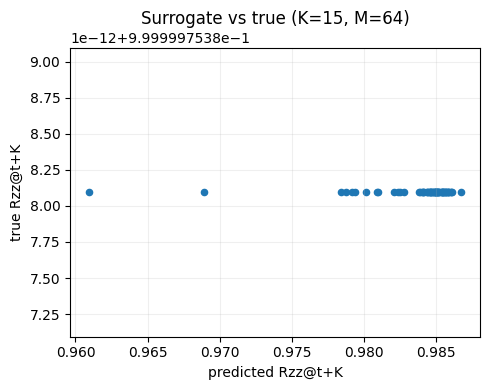

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.scatter(preds, trues, s=20)
plt.xlabel("predicted Rzz@t+K")
plt.ylabel("true Rzz@t+K")
plt.title(f"Surrogate vs true (K={K}, M={len(preds)})")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
idx = np.argsort(preds)
top = trues[idx[-10:]].mean()
bot = trues[idx[:10]].mean()
print("top10 true mean:", top, "bottom10 true mean:", bot, "gap:", top-bot)

In [ ]:
import h5py, numpy as np

rzz_path = "../data/guidance/rzz_mh_can.hdf5"
demo_path = "../data/can/mh/low_dim_v15.hdf5"

interesting = []
with h5py.File(rzz_path, "r") as f:
    for demo_id in f["data"].keys():
        rzz = f["data"][demo_id]["rzz"][:]
        # find timesteps where rzz is noticeably below 1
        idx = np.where(rzz < 0.995)[0]
        if len(idx) > 0:
            interesting.append((demo_id, int(idx[0])))

print("num interesting demos:", len(interesting))
print("example:", interesting[:5])

num interesting demos: 297
example: [('demo_0', 74), ('demo_1', 79), ('demo_10', 75), ('demo_100', 94), ('demo_101', 98)]


In [ ]:
import h5py
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# paths
demo_hdf = "../data/can/mh/low_dim_v15.hdf5"
rzz_hdf  = "../data/guidance/rzz_mh_can.hdf5"

DEMO_ID = "demo_0"   # change if desired
K = 15              # must match your surrogate checkpoint
M = 30              # DP samples per state
body_name = "Can_main"

# DP slicing
To = 2
start = To - 1  # 1

STATE_KEYS = [
    "object",
    "robot0_eef_pos",
    "robot0_eef_quat",
    "robot0_gripper_qpos",
    "robot0_gripper_qvel",
    "robot0_joint_pos",
    "robot0_joint_vel",
]

def build_state_vector_from_stacked_obs(obs, idx=1):
    parts = []
    for k in STATE_KEYS:
        v = obs[k]
        if v.ndim == 2:
            v = v[idx]
        parts.append(v.reshape(-1))
    return np.concatenate(parts, axis=0).astype(np.float32)

def get_rzz(env, body_name="Can_main"):
    sim = env.env.env.sim
    bid = sim.model.body_name2id(body_name)
    return float(sim.data.body_xmat[bid].reshape(3,3)[2,2])

def eval_state(state_dict, make_scatter=False, title=""):
    # reset to given state, get obs for surrogate + policy
    obs = env.reset_to(state_dict)
    s = build_state_vector_from_stacked_obs(obs, idx=1)

    preds, trues = [], []
    for i in range(M):
        # always reset so candidates are comparable
        obs = env.reset_to(state_dict)
        s = build_state_vector_from_stacked_obs(obs, idx=1)

        obs_torch = policy._prepare_observation(obs)
        with torch.no_grad():
            naction = policy.policy.get_full_action(obs_torch)
        naction = np.array(naction)
        if naction.ndim == 3:
            naction = naction[0]  # (Tp,7)

        a_chunk = naction[start:start+K]              # (K,7)
        a_flat  = a_chunk.reshape(-1).astype(np.float32)

        # surrogate pred
        with torch.no_grad():
            s_t = torch.from_numpy(s).unsqueeze(0).to(device)
            a_t = torch.from_numpy(a_flat).unsqueeze(0).to(device)
            p = model(s_norm(s_t), a_norm(a_t)).item()
        preds.append(p)

        # true rollout
        for j in range(K):
            env.step(a_chunk[j])
        trues.append(get_rzz(env, body_name=body_name))

    preds = np.array(preds)
    trues = np.array(trues)

    true_std = float(trues.std())
    pearson = float(np.corrcoef(preds, trues)[0,1]) if true_std > 0 else float("nan")
    spearman = float(spearmanr(preds, trues).correlation) if true_std > 0 else float("nan")

    idx = np.argsort(preds)
    top = float(trues[idx[-10:]].mean())
    bot = float(trues[idx[:10]].mean())
    gap = top - bot

    print(f"{title} true_mean={trues.mean():.6f} true_std={true_std:.3e} "
          f"pearson={pearson:.3f} spearman={spearman:.3f} gap(top10-bot10)={gap:.3e}")

    if make_scatter:
        plt.figure(figsize=(4,3))
        plt.scatter(preds, trues, s=18)
        plt.xlabel("pred")
        plt.ylabel("true Rzz@t+K")
        plt.title(title)
        plt.grid(True, alpha=0.2)
        plt.tight_layout()
        plt.show()

# ---- pick diverse timesteps in one demo by rzz quantiles ----
with h5py.File(demo_hdf, "r") as fD, h5py.File(rzz_hdf, "r") as fR:
    states = fD["data"][DEMO_ID]["states"][:]   # (T,71)
    rzz = fR["data"][DEMO_ID]["rzz"][:]         # (T,)

T = len(rzz)
# ignore last K because we need to roll K steps
valid = np.arange(0, T-K)

# choose 8 timesteps spread over rzz distribution
qs = np.linspace(0.05, 0.95, 8)
t_choices = []
for q in qs:
    thr = np.quantile(rzz[valid], q)
    # pick a timestep closest to that rzz level
    t = int(valid[np.argmin(np.abs(rzz[valid] - thr))])
    t_choices.append(t)

t_choices = sorted(set(t_choices))
print("chosen timesteps:", t_choices[-5:])
print("rzz at chosen:", [float(rzz[t]) for t in t_choices])

# template state dict
env.reset()
template = env.get_state()

# ---- evaluate each chosen timestep ----
for t in t_choices[-5:]:
    sd = template.copy()
    sd["states"] = states[t].copy()
    eval_state(sd, make_scatter=True, title=f"{DEMO_ID} t={t} rzz_now={rzz[t]:.3f}")

chosen timesteps: [12, 61, 71, 84, 97]
rzz at chosen: [0.9999999403953552, 0.9999998211860657, 0.9999998807907104, 0.9999997019767761, 0.9998884201049805, 0.9973787069320679, 0.9845449924468994, 0.9713233113288879]
